In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load optimized data
with open('../../data/train_test_optimized.pkl', 'rb') as f:
    df = pickle.load(f)

print("="*80)
print("DATASET INFO")
print("="*80)
print(f"Total records: {len(df):,}")
print(f"Train records: {(df['_source'] == 'train').sum():,}")
print(f"Test records: {(df['_source'] == 'test').sum():,}")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nFraud rate (train): {df[df['_source']=='train']['isFraud'].mean()*100:.2f}%")

DATASET INFO
Total records: 1,097,231
Train records: 590,540
Test records: 506,691
Memory: 1578.35 MB

Fraud rate (train): 3.50%


In [3]:
# ==================== TEMPORAL FEATURES ====================
# Create week_num and month_num for aggregations (will be dropped later)

df['week_num'] = (df['TransactionDT'] // 604800).astype('int16')  # 1 week = 604800 seconds
df['month_num'] = (df['week_num'] // 4).astype('int16')  # ~4 weeks = 1 month

print("="*80)
print("TEMPORAL FEATURES CREATED")
print("="*80)
print(f"✓ Week range: {df['week_num'].min()} to {df['week_num'].max()}")
print(f"✓ Month range: {df['month_num'].min()} to {df['month_num'].max()}")
print(f"✓ Total weeks: {df['week_num'].nunique()}")
print(f"✓ Total months: {df['month_num'].nunique()}")
print(f"\nNote: These are temporary columns for aggregation, will be removed at cleanup step")
print("="*80)

TEMPORAL FEATURES CREATED
✓ Week range: 0 to 56
✓ Month range: 0 to 14
✓ Total weeks: 54
✓ Total months: 15

Note: These are temporary columns for aggregation, will be removed at cleanup step


## STEP 1: Identity Resolution - Kimlik Tespiti

Aynı kullanıcıyı tespit etmek için güçlü identity fingerprint'ler oluşturacağız.

In [4]:
# ==================== IDENTITY 1: EMAIL + ADDRESS ====================
# En güçlü kimlik sinyali - Aynı email ve adresten işlemler

if 'P_emaildomain' in df.columns and 'addr1' in df.columns:
    df['identity_email_addr'] = (
        df['P_emaildomain'].astype(str) + '_' + 
        df['addr1'].astype(str)
    )
    
    n_unique = df['identity_email_addr'].nunique()
    print(f"✓ Email+Address Identity: {n_unique:,} unique identities")
    print(f"  - Avg transactions per identity: {len(df)/n_unique:.2f}")
else:
    print("⚠️ Email or Address columns not found")

print(f"\nDataset shape: {df.shape}")

✓ Email+Address Identity: 2,576 unique identities
  - Avg transactions per identity: 425.94

Dataset shape: (1097231, 476)


In [5]:
# ==================== IDENTITY 2: DEVICE + ADDRESS ====================
# Fiziksel konuma bağlı cihaz kullanımı

if 'DeviceInfo' in df.columns and 'addr1' in df.columns:
    df['identity_device_addr'] = (
        df['DeviceInfo'].astype(str) + '_' + 
        df['addr1'].astype(str)
    )
    
    n_unique = df['identity_device_addr'].nunique()
    print(f"✓ Device+Address Identity: {n_unique:,} unique identities")
    print(f"  - Avg transactions per identity: {len(df)/n_unique:.2f}")
else:
    print("⚠️ DeviceInfo or Address columns not found")

print(f"\nDataset shape: {df.shape}")

✓ Device+Address Identity: 6,774 unique identities
  - Avg transactions per identity: 161.98

Dataset shape: (1097231, 477)


In [6]:
# ==================== IDENTITY 3: CARD FAMILY ====================
# card2-6 benzerliği ile aynı banka/kişi ailesi

card_cols = [col for col in df.columns if col.startswith('card') and col != 'card1']

if card_cols:
    # Card family: card2-6 kombinasyonu
    df['identity_card_family'] = df[card_cols].apply(
        lambda row: '_'.join(row.astype(str)), axis=1
    )
    
    n_unique = df['identity_card_family'].nunique()
    print(f"✓ Card Family Identity: {n_unique:,} unique families")
    print(f"  - Card columns used: {card_cols}")
    print(f"  - Avg transactions per family: {len(df)/n_unique:.2f}")
else:
    print("⚠️ Card columns not found")

print(f"\nDataset shape: {df.shape}")

✓ Card Family Identity: 3,210 unique families
  - Card columns used: ['card2', 'card3', 'card4', 'card5', 'card6']
  - Avg transactions per family: 341.82

Dataset shape: (1097231, 478)


In [7]:
# ==================== IDENTITY SUMMARY ====================

identity_cols = [col for col in df.columns if col.startswith('identity_')]

print("="*80)
print("IDENTITY RESOLUTION SUMMARY")
print("="*80)

for col in identity_cols:
    n_unique = df[col].nunique()
    avg_txn = len(df) / n_unique
    
    # Multi-card usage: Aynı identity ile kaç farklı card1
    multi_card = df.groupby(col)['card1'].nunique()
    multi_card_pct = (multi_card > 1).sum() / len(multi_card) * 100
    
    print(f"\n{col}:")
    print(f"  - Unique identities: {n_unique:,}")
    print(f"  - Avg transactions: {avg_txn:.2f}")
    print(f"  - Multi-card identities: {multi_card_pct:.1f}%")

print(f"\n{'='*80}")

IDENTITY RESOLUTION SUMMARY

identity_email_addr:
  - Unique identities: 2,576
  - Avg transactions: 425.94
  - Multi-card identities: 69.4%

identity_email_addr:
  - Unique identities: 2,576
  - Avg transactions: 425.94
  - Multi-card identities: 69.4%

identity_device_addr:
  - Unique identities: 6,774
  - Avg transactions: 161.98
  - Multi-card identities: 35.3%

identity_device_addr:
  - Unique identities: 6,774
  - Avg transactions: 161.98
  - Multi-card identities: 35.3%

identity_card_family:
  - Unique identities: 3,210
  - Avg transactions: 341.82
  - Multi-card identities: 42.2%


identity_card_family:
  - Unique identities: 3,210
  - Avg transactions: 341.82
  - Multi-card identities: 42.2%



## STEP 2: Temporal Features - Zaman Bilgisi

Haftalık ve aylık agregasyonlar için zaman feature'ları oluşturalım.

In [8]:
# ==================== UID (User ID) & USER ANCHOR ====================

print("="*80)
print("CORE USER IDENTIFICATION FEATURES")
print("="*80)

# 1. UID: card1 + addr1 kombinasyonu (04'teki en başarılı approach)
df['uid_card1_addr1'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str)
print(f"\n✓ UID created: {df['uid_card1_addr1'].nunique():,} unique users")

# 2. USER ANCHOR D1 - En önemli feature (12.90% importance)
# TransactionDT - D1*86400 gives consistent anchor per user
df['user_anchor_D1'] = df['TransactionDT'] - (df['D1'] * 86400)
print(f"✓ User Anchor D1 created: {df['user_anchor_D1'].nunique():,} unique anchors")
print(f"  - Missing: {df['user_anchor_D1'].isna().sum():,} ({df['user_anchor_D1'].isna().mean()*100:.1f}%)")

print(f"\n{'='*80}")
print(f"Dataset shape: {df.shape}")
print(f"{'='*80}")

CORE USER IDENTIFICATION FEATURES

✓ UID created: 51,664 unique users
✓ User Anchor D1 created: 1,071,580 unique anchors
  - Missing: 7,300 (0.7%)

Dataset shape: (1097231, 480)

✓ UID created: 51,664 unique users
✓ User Anchor D1 created: 1,071,580 unique anchors
  - Missing: 7,300 (0.7%)

Dataset shape: (1097231, 480)


In [9]:
# ==================== UID BEHAVIORAL FEATURES ====================
# 04'te Top 20'de olan: uid_avg_amt, uid_max_amt, uid_min_amt, uid_std_amt, uid_txn_count, etc.

print("="*80)
print("UID BEHAVIORAL FEATURES (Top Priority - Based on 04 Model)")
print("="*80)

# 1. GENERAL STATISTICS
print("\n1. General UID statistics...")
uid_general_agg = df.groupby('uid_card1_addr1').agg({
    'TransactionAmt': ['mean', 'std', 'max', 'min', 'sum', 'count']
})

uid_general_agg.columns = ['uid_avg_amt', 'uid_std_amt', 'uid_max_amt', 
                            'uid_min_amt', 'uid_total_amt', 'uid_txn_count']
uid_general_agg = uid_general_agg.reset_index()

df = df.merge(uid_general_agg, on='uid_card1_addr1', how='left')
print(f"   ✓ Added: uid_avg_amt (2.71% imp), uid_max_amt (2.65%), uid_min_amt (2.61%), uid_std_amt (2.07%), uid_txn_count (2.06%)")

# 2. WEEKLY STATISTICS
print("\n2. Weekly UID statistics...")
uid_weekly_agg = df.groupby(['uid_card1_addr1', 'week_num']).agg({
    'TransactionAmt': ['mean', 'count']
})

uid_weekly_agg.columns = ['uid_week_avg_amt', 'uid_week_txn_count']
uid_weekly_agg = uid_weekly_agg.reset_index()

df = df.merge(uid_weekly_agg, on=['uid_card1_addr1', 'week_num'], how='left')
print(f"   ✓ Added: uid_week_avg_amt, uid_week_txn_count (2.55% imp)")

# 3. MONTHLY STATISTICS
print("\n3. Monthly UID statistics...")
uid_monthly_agg = df.groupby(['uid_card1_addr1', 'month_num']).agg({
    'TransactionAmt': ['mean', 'count']
})

uid_monthly_agg.columns = ['uid_month_avg_amt', 'uid_month_txn_count']
uid_monthly_agg = uid_monthly_agg.reset_index()

df = df.merge(uid_monthly_agg, on=['uid_card1_addr1', 'month_num'], how='left')
print(f"   ✓ Added: uid_month_avg_amt (2.39% imp), uid_month_txn_count (2.30% imp)")

# 4. ANOMALY DETECTION RATIOS
print("\n4. UID anomaly detection ratios...")
df['amt_vs_uid_avg'] = df['TransactionAmt'] / (df['uid_avg_amt'] + 1)
df['amt_vs_uid_week_avg'] = df['TransactionAmt'] / (df['uid_week_avg_amt'] + 1)
df['amt_vs_uid_month_avg'] = df['TransactionAmt'] / (df['uid_month_avg_amt'] + 1)
print(f"   ✓ Added: amt vs avg ratios (anomaly detection)")

print(f"\n{'='*80}")
print(f"UID features created. Shape: {df.shape}")
print(f"{'='*80}")

UID BEHAVIORAL FEATURES (Top Priority - Based on 04 Model)

1. General UID statistics...
   ✓ Added: uid_avg_amt (2.71% imp), uid_max_amt (2.65%), uid_min_amt (2.61%), uid_std_amt (2.07%), uid_txn_count (2.06%)

2. Weekly UID statistics...
   ✓ Added: uid_avg_amt (2.71% imp), uid_max_amt (2.65%), uid_min_amt (2.61%), uid_std_amt (2.07%), uid_txn_count (2.06%)

2. Weekly UID statistics...
   ✓ Added: uid_week_avg_amt, uid_week_txn_count (2.55% imp)

3. Monthly UID statistics...
   ✓ Added: uid_week_avg_amt, uid_week_txn_count (2.55% imp)

3. Monthly UID statistics...
   ✓ Added: uid_month_avg_amt (2.39% imp), uid_month_txn_count (2.30% imp)

4. UID anomaly detection ratios...
   ✓ Added: amt vs avg ratios (anomaly detection)

UID features created. Shape: (1097231, 493)
   ✓ Added: uid_month_avg_amt (2.39% imp), uid_month_txn_count (2.30% imp)

4. UID anomaly detection ratios...
   ✓ Added: amt vs avg ratios (anomaly detection)

UID features created. Shape: (1097231, 493)


In [10]:
# ==================== CARD1 STATISTICS ====================
# 04'te önemli çıkan: amt_mean, amt_max, amt_std, n_devices

print("="*80)
print("CARD1 AGGREGATED STATISTICS")
print("="*80)

card1_agg = df.groupby('card1').agg({
    'TransactionAmt': ['mean', 'std', 'max'],
    'addr1': 'nunique',
    'DeviceInfo': 'nunique'
}).reset_index()

card1_agg.columns = ['card1', 'amt_mean', 'amt_std', 'amt_max', 'n_addr', 'n_devices']

df = df.merge(card1_agg, on='card1', how='left')

print(f"\n✓ Card1 statistics added:")
print(f"  - amt_mean (5.61% importance in 04)")
print(f"  - amt_std (2.49% importance)")
print(f"  - amt_max (2.69% importance)")
print(f"  - n_addr: unique addresses per card")
print(f"  - n_devices (2.07% importance)")

print(f"\n{'='*80}")
print(f"Dataset shape: {df.shape}")
print(f"{'='*80}")

CARD1 AGGREGATED STATISTICS

✓ Card1 statistics added:
  - amt_mean (5.61% importance in 04)
  - amt_std (2.49% importance)
  - amt_max (2.69% importance)
  - n_addr: unique addresses per card
  - n_devices (2.07% importance)

Dataset shape: (1097231, 498)

✓ Card1 statistics added:
  - amt_mean (5.61% importance in 04)
  - amt_std (2.49% importance)
  - amt_max (2.69% importance)
  - n_addr: unique addresses per card
  - n_devices (2.07% importance)

Dataset shape: (1097231, 498)


In [11]:
# ==================== PSYCHOLOGICAL AMOUNT FEATURES ====================
# İnsanlar belirli sayıları tercih eder: yuvarlak (100, 500), psikolojik (99, 199)
# Fraud botları genellikle random sayılar üretir

print("="*80)
print("PSYCHOLOGICAL AMOUNT ANALYSIS")
print("="*80)

def classify_amount_type(amount):
    """
    TransactionAmt'yi 3 kategoriye ayır (dolar ve cent kısmı birlikte):
    - 'round': Yuvarlak sayılar (10.00, 50.00, 100.00, 500.00)
    - 'psychological': Psikolojik sayılar (9.99, 49.99, 99.95, 199.99)
    - 'random': Diğer sayılar (gerçek işlemler: 123.47, 87.32)
    """
    # Tam sayı ve cent kısmı
    int_part = int(amount)
    cents = round((amount - int_part) * 100)  # Cent kısmı (0-99)
    
    # 1. YUVARLAK SAYILAR (tam dolar, cent = 00)
    if cents == 0:
        # 100.00, 200.00, 500.00, 1000.00
        if int_part % 100 == 0 or int_part % 50 == 0 or int_part % 10 == 0:
            return 'round'
    
    # 2. PSİKOLOJİK SAYILAR (cent kısmı önemli)
    # 9.99, 19.99, 49.99, 99.99, 199.99, 499.99
    if cents == 99:
        return 'psychological'
    
    # 9.95, 19.95, 49.95, 99.95, 199.95
    if cents == 95:
        return 'psychological'
    
    # 9.90, 19.90, 49.90 (cent = 90)
    if cents == 90:
        last_digit = int_part % 10
        if last_digit == 9:  # 9.90, 19.90, 29.90
            return 'psychological'
    
    # Tam sayı kısmı psikolojik ve cent == 0: 99.00, 49.00
    if cents == 0:
        last_digit = int_part % 10
        if last_digit == 9 or last_digit == 5:
            return 'psychological'
    
    # 3. DİĞER HER ŞEY RANDOM
    return 'random'

# Feature oluştur
df['amt_type'] = df['TransactionAmt'].apply(classify_amount_type)

# İstatistikler
print(f"\n📊 Amount Type Distribution:")
amt_dist = df['amt_type'].value_counts()
for amt_type, count in amt_dist.items():
    pct = count / len(df) * 100
    print(f"  - {amt_type:<15}: {count:>8,} ({pct:>5.1f}%)")

# Train data için fraud rate analizi
if 'isFraud' in df.columns:
    train_mask = df['_source'] == 'train'
    print(f"\n🔍 Fraud Rate by Amount Type (Train Data):")
    
    for amt_type in ['round', 'psychological', 'random']:
        mask = train_mask & (df['amt_type'] == amt_type)
        if mask.sum() > 0:
            fraud_rate = df[mask]['isFraud'].mean() * 100
            count = mask.sum()
            print(f"  - {amt_type:<15}: {fraud_rate:>5.2f}% fraud ({count:,} txns)")

# Ek binary features
df['is_round_amount'] = (df['amt_type'] == 'round').astype('int8')
df['is_psych_amount'] = (df['amt_type'] == 'psychological').astype('int8')
df['is_random_amount'] = (df['amt_type'] == 'random').astype('int8')

# Cent analizi (decimal kısım)
df['amt_cents'] = ((df['TransactionAmt'] - df['TransactionAmt'].astype(int)) * 100).round().astype('int16')
df['has_cents'] = (df['amt_cents'] > 0).astype('int8')  # Cent var mı?
df['is_99_cents'] = (df['amt_cents'] == 99).astype('int8')  # .99 ile mi bitiyor?
df['is_95_cents'] = (df['amt_cents'] == 95).astype('int8')  # .95 ile mi bitiyor?
df['is_round_cents'] = (df['amt_cents'] % 10 == 0).astype('int8')  # .00, .10, .20, ... gibi

print(f"\n✓ Created features:")
print(f"  - amt_type (categorical: round/psychological/random)")
print(f"  - is_round_amount (binary)")
print(f"  - is_psych_amount (binary)")
print(f"  - is_random_amount (binary)")
print(f"  - amt_cents (0-99)")
print(f"  - has_cents (binary)")
print(f"  - is_99_cents (binary)")
print(f"  - is_95_cents (binary)")
print(f"  - is_round_cents (binary)")

print(f"\n{'='*80}")
print(f"Dataset shape: {df.shape}")
print(f"{'='*80}")

PSYCHOLOGICAL AMOUNT ANALYSIS

📊 Amount Type Distribution:
  - psychological  :  522,060 ( 47.6%)
  - random         :  422,554 ( 38.5%)
  - round          :  152,617 ( 13.9%)

🔍 Fraud Rate by Amount Type (Train Data):

📊 Amount Type Distribution:
  - psychological  :  522,060 ( 47.6%)
  - random         :  422,554 ( 38.5%)
  - round          :  152,617 ( 13.9%)

🔍 Fraud Rate by Amount Type (Train Data):
  - round          :  4.45% fraud (81,235 txns)
  - round          :  4.45% fraud (81,235 txns)
  - psychological  :  1.58% fraud (281,107 txns)
  - psychological  :  1.58% fraud (281,107 txns)
  - random         :  5.53% fraud (228,198 txns)
  - random         :  5.53% fraud (228,198 txns)

✓ Created features:
  - amt_type (categorical: round/psychological/random)
  - is_round_amount (binary)
  - is_psych_amount (binary)
  - is_random_amount (binary)
  - amt_cents (0-99)
  - has_cents (binary)
  - is_99_cents (binary)
  - is_95_cents (binary)
  - is_round_cents (binary)

Dataset shape

## STEP 3: Temporal Features - Zaman Bilgisi

Haftalık ve aylık agregasyonlar için zaman feature'ları oluşturalım.

## STEP 3: Behavioral Features by Identity

Her identity için davranışsal özellikler oluşturacağız. En güçlü identity olan **Email+Address** ile başlıyoruz.

In [12]:
# ==================== EMAIL+ADDR BEHAVIORAL FEATURES ====================

identity_col = 'identity_email_addr'

if identity_col in df.columns:
    print("="*80)
    print(f"Creating features for: {identity_col}")
    print("="*80)
    
    # 1. GENERAL STATISTICS (Genel istatistikler)
    print("\n1. General statistics...")
    general_agg = df.groupby(identity_col).agg({
        'TransactionAmt': ['mean', 'std', 'max', 'min', 'sum', 'count']
    })
    
    general_agg.columns = [
        'ea_avg_amt', 'ea_std_amt', 'ea_max_amt', 
        'ea_min_amt', 'ea_total_amt', 'ea_txn_count'
    ]
    general_agg = general_agg.reset_index()
    
    df = df.merge(general_agg, on=identity_col, how='left')
    print(f"   ✓ Added: avg, std, max, min, total, count")
    
    # 2. WEEKLY STATISTICS (Haftalık istatistikler)
    print("\n2. Weekly statistics...")
    weekly_agg = df.groupby([identity_col, 'week_num']).agg({
        'TransactionAmt': ['mean', 'count']
    })
    
    weekly_agg.columns = ['ea_week_avg_amt', 'ea_week_txn_count']
    weekly_agg = weekly_agg.reset_index()
    
    df = df.merge(weekly_agg, on=[identity_col, 'week_num'], how='left')
    print(f"   ✓ Added: weekly avg amount, weekly txn count")
    
    # 3. MONTHLY STATISTICS (Aylık istatistikler)
    print("\n3. Monthly statistics...")
    monthly_agg = df.groupby([identity_col, 'month_num']).agg({
        'TransactionAmt': ['mean', 'count']
    })
    
    monthly_agg.columns = ['ea_month_avg_amt', 'ea_month_txn_count']
    monthly_agg = monthly_agg.reset_index()
    
    df = df.merge(monthly_agg, on=[identity_col, 'month_num'], how='left')
    print(f"   ✓ Added: monthly avg amount, monthly txn count")
    
    # 4. ANOMALY DETECTION RATIOS (Anomali tespiti oranları)
    print("\n4. Anomaly detection ratios...")
    df['ea_amt_vs_avg'] = df['TransactionAmt'] / (df['ea_avg_amt'] + 1)
    df['ea_amt_vs_week_avg'] = df['TransactionAmt'] / (df['ea_week_avg_amt'] + 1)
    df['ea_amt_vs_month_avg'] = df['TransactionAmt'] / (df['ea_month_avg_amt'] + 1)
    print(f"   ✓ Added: amount vs avg, vs week avg, vs month avg")
    
    print(f"\n{'='*80}")
    print(f"Email+Addr features created. Shape: {df.shape}")
    print(f"{'='*80}")

Creating features for: identity_email_addr

1. General statistics...
   ✓ Added: avg, std, max, min, total, count

2. Weekly statistics...
   ✓ Added: avg, std, max, min, total, count

2. Weekly statistics...
   ✓ Added: weekly avg amount, weekly txn count

3. Monthly statistics...
   ✓ Added: weekly avg amount, weekly txn count

3. Monthly statistics...
   ✓ Added: monthly avg amount, monthly txn count

4. Anomaly detection ratios...
   ✓ Added: amount vs avg, vs week avg, vs month avg

Email+Addr features created. Shape: (1097231, 520)
   ✓ Added: monthly avg amount, monthly txn count

4. Anomaly detection ratios...
   ✓ Added: amount vs avg, vs week avg, vs month avg

Email+Addr features created. Shape: (1097231, 520)


In [13]:
# ==================== DEVICE+ADDR BEHAVIORAL FEATURES ====================

identity_col = 'identity_device_addr'

if identity_col in df.columns:
    print("="*80)
    print(f"Creating features for: {identity_col}")
    print("="*80)
    
    # 1. GENERAL STATISTICS
    print("\n1. General statistics...")
    general_agg = df.groupby(identity_col).agg({
        'TransactionAmt': ['mean', 'std', 'max', 'min', 'count']
    })
    
    general_agg.columns = [
        'da_avg_amt', 'da_std_amt', 'da_max_amt', 
        'da_min_amt', 'da_txn_count'
    ]
    general_agg = general_agg.reset_index()
    
    df = df.merge(general_agg, on=identity_col, how='left')
    print(f"   ✓ Added: avg, std, max, min, count")
    
    # 2. WEEKLY STATISTICS
    print("\n2. Weekly statistics...")
    weekly_agg = df.groupby([identity_col, 'week_num']).agg({
        'TransactionAmt': ['mean', 'count']
    })
    
    weekly_agg.columns = ['da_week_avg_amt', 'da_week_txn_count']
    weekly_agg = weekly_agg.reset_index()
    
    df = df.merge(weekly_agg, on=[identity_col, 'week_num'], how='left')
    print(f"   ✓ Added: weekly avg amount, weekly txn count")
    
    # 3. ANOMALY DETECTION RATIOS
    print("\n3. Anomaly detection ratios...")
    df['da_amt_vs_avg'] = df['TransactionAmt'] / (df['da_avg_amt'] + 1)
    df['da_amt_vs_week_avg'] = df['TransactionAmt'] / (df['da_week_avg_amt'] + 1)
    print(f"   ✓ Added: amount vs avg, vs week avg")
    
    print(f"\n{'='*80}")
    print(f"Device+Addr features created. Shape: {df.shape}")
    print(f"{'='*80}")

Creating features for: identity_device_addr

1. General statistics...
   ✓ Added: avg, std, max, min, count

2. Weekly statistics...
   ✓ Added: avg, std, max, min, count

2. Weekly statistics...
   ✓ Added: weekly avg amount, weekly txn count

3. Anomaly detection ratios...
   ✓ Added: amount vs avg, vs week avg

Device+Addr features created. Shape: (1097231, 529)
   ✓ Added: weekly avg amount, weekly txn count

3. Anomaly detection ratios...
   ✓ Added: amount vs avg, vs week avg

Device+Addr features created. Shape: (1097231, 529)


In [14]:
# ==================== CARD FAMILY BEHAVIORAL FEATURES ====================

identity_col = 'identity_card_family'

if identity_col in df.columns:
    print("="*80)
    print(f"Creating features for: {identity_col}")
    print("="*80)
    
    # 1. GENERAL STATISTICS
    print("\n1. General statistics...")
    general_agg = df.groupby(identity_col).agg({
        'TransactionAmt': ['mean', 'std', 'count'],
        'card1': 'nunique'  # Kaç farklı card1 kullanılıyor
    })
    
    general_agg.columns = [
        'cf_avg_amt', 'cf_std_amt', 'cf_txn_count', 'cf_unique_cards'
    ]
    general_agg = general_agg.reset_index()
    
    df = df.merge(general_agg, on=identity_col, how='left')
    print(f"   ✓ Added: avg, std, count, unique cards")
    
    # 2. WEEKLY STATISTICS
    print("\n2. Weekly statistics...")
    weekly_agg = df.groupby([identity_col, 'week_num']).agg({
        'TransactionAmt': 'mean'
    }).reset_index()
    
    weekly_agg.columns = [identity_col, 'week_num', 'cf_week_avg_amt']
    
    df = df.merge(weekly_agg, on=[identity_col, 'week_num'], how='left')
    print(f"   ✓ Added: weekly avg amount")
    
    # 3. ANOMALY DETECTION RATIOS
    print("\n3. Anomaly detection ratios...")
    df['cf_amt_vs_avg'] = df['TransactionAmt'] / (df['cf_avg_amt'] + 1)
    print(f"   ✓ Added: amount vs avg")
    
    print(f"\n{'='*80}")
    print(f"Card Family features created. Shape: {df.shape}")
    print(f"{'='*80}")

Creating features for: identity_card_family

1. General statistics...
   ✓ Added: avg, std, count, unique cards

2. Weekly statistics...
   ✓ Added: avg, std, count, unique cards

2. Weekly statistics...
   ✓ Added: weekly avg amount

3. Anomaly detection ratios...
   ✓ Added: amount vs avg

Card Family features created. Shape: (1097231, 535)
   ✓ Added: weekly avg amount

3. Anomaly detection ratios...
   ✓ Added: amount vs avg

Card Family features created. Shape: (1097231, 535)


## STEP 4: Multi-Card Risk Indicators

Her identity için multi-card kullanımını ve risk skorlarını hesaplayalım.

In [15]:
# ==================== MULTI-CARD DETECTION ====================

print("="*80)
print("MULTI-CARD RISK INDICATORS")
print("="*80)

# 1. Email+Address: Kaç farklı kart kullanılıyor
if 'identity_email_addr' in df.columns:
    ea_card_count = df.groupby('identity_email_addr')['card1'].nunique()
    df['ea_card_count'] = df['identity_email_addr'].map(ea_card_count)
    df['is_multi_card_email_addr'] = (df['ea_card_count'] > 1).astype('int8')
    
    print(f"\n✓ Email+Address multi-card detection:")
    print(f"  - Max cards per identity: {df['ea_card_count'].max()}")
    print(f"  - Multi-card identities: {df['is_multi_card_email_addr'].sum():,} transactions")

# 2. Device+Address: Kaç farklı kart kullanılıyor
if 'identity_device_addr' in df.columns:
    da_card_count = df.groupby('identity_device_addr')['card1'].nunique()
    df['da_card_count'] = df['identity_device_addr'].map(da_card_count)
    df['is_multi_card_device_addr'] = (df['da_card_count'] > 1).astype('int8')
    
    print(f"\n✓ Device+Address multi-card detection:")
    print(f"  - Max cards per identity: {df['da_card_count'].max()}")
    print(f"  - Multi-card identities: {df['is_multi_card_device_addr'].sum():,} transactions")

# 3. Card Family: Zaten cf_unique_cards var
if 'cf_unique_cards' in df.columns:
    df['is_multi_card_family'] = (df['cf_unique_cards'] > 1).astype('int8')
    
    print(f"\n✓ Card Family multi-card detection:")
    print(f"  - Max cards per family: {df['cf_unique_cards'].max()}")
    print(f"  - Multi-card families: {df['is_multi_card_family'].sum():,} transactions")

# 4. COMBINED RISK SCORE
multi_card_flags = [col for col in df.columns if col.startswith('is_multi_card_')]
if multi_card_flags:
    df['multi_card_risk_score'] = df[multi_card_flags].sum(axis=1).astype('int8')
    
    print(f"\n✓ Combined risk score created from {len(multi_card_flags)} signals")
    print(f"\nRisk score distribution:")
    print(df['multi_card_risk_score'].value_counts().sort_index())

print(f"\n{'='*80}")
print(f"Multi-card features created. Shape: {df.shape}")
print(f"{'='*80}")

MULTI-CARD RISK INDICATORS

✓ Email+Address multi-card detection:
  - Max cards per identity: 1631.0
  - Multi-card identities: 964,702 transactions

✓ Email+Address multi-card detection:
  - Max cards per identity: 1631.0
  - Multi-card identities: 964,702 transactions

✓ Device+Address multi-card detection:
  - Max cards per identity: 1852.0
  - Multi-card identities: 960,536 transactions

✓ Card Family multi-card detection:
  - Max cards per family: 2679
  - Multi-card families: 959,580 transactions

✓ Device+Address multi-card detection:
  - Max cards per identity: 1852.0
  - Multi-card identities: 960,536 transactions

✓ Card Family multi-card detection:
  - Max cards per family: 2679
  - Multi-card families: 959,580 transactions

✓ Combined risk score created from 3 signals

Risk score distribution:
multi_card_risk_score
0     17207
1    115244
2    124766
3    840014
Name: count, dtype: int64

Multi-card features created. Shape: (1097231, 541)

✓ Combined risk score created from

## STEP 5: New User Indicators & Missing Value Strategy

Yeni kullanıcıları işaretleyip, eksik değerleri akıllı şekilde dolduracağız.

In [16]:
# ==================== NEW USER INDICATORS ====================

print("="*80)
print("NEW USER DETECTION & MISSING VALUE HANDLING")
print("="*80)

# 1. Email+Address: Yeni kullanıcı mı?
if 'ea_avg_amt' in df.columns:
    df['ea_is_new'] = df['ea_avg_amt'].isna().astype('int8')
    print(f"\n✓ Email+Address new users: {df['ea_is_new'].sum():,} ({df['ea_is_new'].mean()*100:.2f}%)")

# 2. Device+Address: Yeni kullanıcı mı?
if 'da_avg_amt' in df.columns:
    df['da_is_new'] = df['da_avg_amt'].isna().astype('int8')
    print(f"✓ Device+Address new users: {df['da_is_new'].sum():,} ({df['da_is_new'].mean()*100:.2f}%)")

# 3. Card Family: Yeni aile mi?
if 'cf_avg_amt' in df.columns:
    df['cf_is_new'] = df['cf_avg_amt'].isna().astype('int8')
    print(f"✓ Card Family new families: {df['cf_is_new'].sum():,} ({df['cf_is_new'].mean()*100:.2f}%)")

print(f"\n{'='*80}")

NEW USER DETECTION & MISSING VALUE HANDLING

✓ Email+Address new users: 131,315 (11.97%)
✓ Device+Address new users: 131,315 (11.97%)
✓ Card Family new families: 0 (0.00%)



In [17]:
# ==================== SMART MISSING VALUE FILLING ====================

print("\nFilling missing values with smart strategy...\n")

# Strategy:
# - Aggregation features (avg, std, count) → 0 (no history)
# - Ratio features (amt vs avg) → 1.0 (neutral)

# Email+Address features
ea_agg_features = ['ea_avg_amt', 'ea_std_amt', 'ea_max_amt', 'ea_min_amt', 
                   'ea_total_amt', 'ea_txn_count', 'ea_week_avg_amt', 
                   'ea_week_txn_count', 'ea_month_avg_amt', 'ea_month_txn_count']

ea_ratio_features = ['ea_amt_vs_avg', 'ea_amt_vs_week_avg', 'ea_amt_vs_month_avg']

for col in ea_agg_features:
    if col in df.columns:
        df[col] = df[col].fillna(0)
        
for col in ea_ratio_features:
    if col in df.columns:
        df[col] = df[col].fillna(1.0)

print("✓ Email+Address features filled")

# Device+Address features
da_agg_features = ['da_avg_amt', 'da_std_amt', 'da_max_amt', 'da_min_amt', 
                   'da_txn_count', 'da_week_avg_amt', 'da_week_txn_count']

da_ratio_features = ['da_amt_vs_avg', 'da_amt_vs_week_avg']

for col in da_agg_features:
    if col in df.columns:
        df[col] = df[col].fillna(0)
        
for col in da_ratio_features:
    if col in df.columns:
        df[col] = df[col].fillna(1.0)

print("✓ Device+Address features filled")

# Card Family features
cf_agg_features = ['cf_avg_amt', 'cf_std_amt', 'cf_txn_count', 
                   'cf_unique_cards', 'cf_week_avg_amt']

cf_ratio_features = ['cf_amt_vs_avg']

for col in cf_agg_features:
    if col in df.columns:
        df[col] = df[col].fillna(0)
        
for col in cf_ratio_features:
    if col in df.columns:
        df[col] = df[col].fillna(1.0)

print("✓ Card Family features filled")

print(f"\n{'='*80}")
print("Missing value handling completed!")
print(f"{'='*80}")


Filling missing values with smart strategy...

✓ Email+Address features filled
✓ Device+Address features filled
✓ Email+Address features filled
✓ Device+Address features filled
✓ Card Family features filled

Missing value handling completed!
✓ Card Family features filled

Missing value handling completed!


## STEP 7: Cleanup & Summary

Geçici sütunları temizleyip, oluşturulan tüm feature'ları özetleyelim.

In [18]:
# ==================== CLEANUP ====================

# Geçici zaman feature'larını sil
temp_cols = ['week_num', 'month_num']
df = df.drop(columns=temp_cols, errors='ignore')

print("✓ Temporary columns removed: week_num, month_num")
print(f"\nFinal dataset shape: {df.shape}")

✓ Temporary columns removed: week_num, month_num

Final dataset shape: (1097231, 542)


In [19]:
# ==================== FEATURE SUMMARY ====================

print("="*80)
print("ADVANCED FEATURE ENGINEERING SUMMARY")
print("="*80)

# Identity features
identity_features = [col for col in df.columns if col.startswith('identity_')]
print(f"\n🔐 IDENTITY FEATURES ({len(identity_features)}):")
for feat in identity_features:
    print(f"  - {feat}")

# Email+Address features
ea_features = [col for col in df.columns if col.startswith('ea_')]
print(f"\n📧 EMAIL+ADDRESS FEATURES ({len(ea_features)}):")
for feat in ea_features:
    print(f"  - {feat}")

# Device+Address features
da_features = [col for col in df.columns if col.startswith('da_')]
print(f"\n📱 DEVICE+ADDRESS FEATURES ({len(da_features)}):")
for feat in da_features:
    print(f"  - {feat}")

# Card Family features
cf_features = [col for col in df.columns if col.startswith('cf_')]
print(f"\n💳 CARD FAMILY FEATURES ({len(cf_features)}):")
for feat in cf_features:
    print(f"  - {feat}")

# Multi-card risk features
risk_features = [col for col in df.columns if 'multi_card' in col or 'is_new' in col]
print(f"\n⚠️ RISK INDICATORS ({len(risk_features)}):")
for feat in risk_features:
    print(f"  - {feat}")

# Total new features
all_new_features = identity_features + ea_features + da_features + cf_features + risk_features
print(f"\n{'='*80}")
print(f"TOTAL NEW FEATURES CREATED: {len(all_new_features)}")
print(f"{'='*80}")

ADVANCED FEATURE ENGINEERING SUMMARY

🔐 IDENTITY FEATURES (3):
  - identity_email_addr
  - identity_device_addr
  - identity_card_family

📧 EMAIL+ADDRESS FEATURES (15):
  - ea_avg_amt
  - ea_std_amt
  - ea_max_amt
  - ea_min_amt
  - ea_total_amt
  - ea_txn_count
  - ea_week_avg_amt
  - ea_week_txn_count
  - ea_month_avg_amt
  - ea_month_txn_count
  - ea_amt_vs_avg
  - ea_amt_vs_week_avg
  - ea_amt_vs_month_avg
  - ea_card_count
  - ea_is_new

📱 DEVICE+ADDRESS FEATURES (11):
  - da_avg_amt
  - da_std_amt
  - da_max_amt
  - da_min_amt
  - da_txn_count
  - da_week_avg_amt
  - da_week_txn_count
  - da_amt_vs_avg
  - da_amt_vs_week_avg
  - da_card_count
  - da_is_new

💳 CARD FAMILY FEATURES (7):
  - cf_avg_amt
  - cf_std_amt
  - cf_txn_count
  - cf_unique_cards
  - cf_week_avg_amt
  - cf_amt_vs_avg
  - cf_is_new

⚠️ RISK INDICATORS (7):
  - is_multi_card_email_addr
  - is_multi_card_device_addr
  - is_multi_card_family
  - multi_card_risk_score
  - ea_is_new
  - da_is_new
  - cf_is_new

TOT

In [ ]:
# ==================== DROP LOW IMPORTANCE FEATURES (DISABLED) ====================
# NOTE: This cell is disabled because these features (_1 suffix) are created AFTER encoding.
# Low importance features will be dropped AFTER encoding in a later cell.

# low_importance_to_drop = [
#     'is_99_cents_1',
#     'has_cents_1',
#     'multi_card_risk_score_3',
#     'is_random_amount_1',
#     'multi_card_risk_score_1',
#     'identity_device_addr_freq',
#     'is_multi_card_family_1',
#     'addr2_freq',
#     'amt_type',
#     'da_is_new_1',
#     'is_psych_amount_1',
#     'ea_is_new_1',
#     'is_95_cents_1',
#     'multi_card_risk_score_2',
#     'is_multi_card_email_addr_1',
#     'is_multi_card_device_addr_1',
#     'is_round_amount_1'
# ]

print("="*80)
print("⚠️ LOW IMPORTANCE DROP - SKIPPED")
print("="*80)
print("This step is now performed AFTER encoding.")
print("See the cell after 'ENCODING & PREPROCESSING' for low importance feature removal.")
print("="*80)

DROPPING LOW IMPORTANCE FEATURES

📋 Features to drop: 17
✓ Found in dataset: 1
⚠️ Not found (already dropped or renamed): 16

Dropping features:
  - amt_type

✓ Dropped 1 features

⚠️ Features not found in dataset:
  - is_99_cents_1
  - has_cents_1
  - multi_card_risk_score_3
  - is_random_amount_1
  - multi_card_risk_score_1
  - identity_device_addr_freq
  - is_multi_card_family_1
  - addr2_freq
  - da_is_new_1
  - is_psych_amount_1
  - ea_is_new_1
  - is_95_cents_1
  - multi_card_risk_score_2
  - is_multi_card_email_addr_1
  - is_multi_card_device_addr_1
  - is_round_amount_1

Dataset shape after dropping: (1097231, 541)

✓ Dropped 1 features

⚠️ Features not found in dataset:
  - is_99_cents_1
  - has_cents_1
  - multi_card_risk_score_3
  - is_random_amount_1
  - multi_card_risk_score_1
  - identity_device_addr_freq
  - is_multi_card_family_1
  - addr2_freq
  - da_is_new_1
  - is_psych_amount_1
  - ea_is_new_1
  - is_95_cents_1
  - multi_card_risk_score_2
  - is_multi_card_email_add

In [21]:
# ==================== FRAUD CORRELATION ANALYSIS ====================

if 'isFraud' in df.columns:
    train_data = df[df['_source'] == 'train'].copy()
    
    # Calculate correlations for new features
    new_numeric_features = [col for col in all_new_features 
                           if col in train_data.columns 
                           and train_data[col].dtype in ['float64', 'float32', 'int64', 'int32', 'int16', 'int8']]
    
    correlations = train_data[new_numeric_features + ['isFraud']].corr()['isFraud'].drop('isFraud')
    correlations = correlations.abs().sort_values(ascending=False)
    
    print("\n" + "="*80)
    print("TOP 20 FEATURES BY FRAUD CORRELATION")
    print("="*80)
    
    for idx, (feat, corr) in enumerate(correlations.head(20).items(), 1):
        print(f"{idx:2d}. {feat:<40} : {corr:.4f}")
    
    print(f"\n{'='*80}")


TOP 20 FEATURES BY FRAUD CORRELATION
 1. is_multi_card_device_addr                : 0.1596
 2. da_is_new                                : 0.1595
 3. ea_is_new                                : 0.1595
 4. ea_is_new                                : 0.1595
 5. da_is_new                                : 0.1595
 6. is_multi_card_email_addr                 : 0.1590
 7. multi_card_risk_score                    : 0.1482
 8. da_std_amt                               : 0.1475
 9. da_avg_amt                               : 0.1445
10. ea_avg_amt                               : 0.1351
11. ea_std_amt                               : 0.1257
12. da_week_avg_amt                          : 0.1233
13. ea_month_avg_amt                         : 0.1037
14. da_max_amt                               : 0.0994
15. ea_max_amt                               : 0.0905
16. da_week_txn_count                        : 0.0869
17. da_txn_count                             : 0.0854
18. ea_week_avg_amt                         

## STEP 8: Save Enhanced Dataset

Oluşturduğumuz feature'larla birlikte dataset'i kaydedelim.

In [22]:
# Save to pickle
output_path = '../../data/train_test_advanced_features.pkl'

with open(output_path, 'wb') as f:
    pickle.dump(df, f)

print("="*80)
print("DATASET SAVED")
print("="*80)
print(f"Path: {output_path}")
print(f"Shape: {df.shape}")
print(f"Size: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nNew features: {len(all_new_features)}")
print("\n✅ Ready for modeling!")

DATASET SAVED
Path: ../../data/train_test_advanced_features.pkl
Shape: (1097231, 541)
Size: 2258.09 MB

New features: 43

✅ Ready for modeling!
Size: 2258.09 MB

New features: 43

✅ Ready for modeling!


## STEP 9: Model Training & Feature Importance Analysis

Oluşturduğumuz feature'ların gerçekten işe yarayıp yaramadığını test edelim ve feature importance'ları görelim.

In [23]:
# ==================== TRAIN/TEST SPLIT ====================

train_df = df[df['_source'] == 'train'].copy()
test_df = df[df['_source'] == 'test'].copy()

print("="*80)
print("TRAIN/TEST SPLIT")
print("="*80)
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Train fraud rate: {train_df['isFraud'].mean()*100:.2f}%")

# Drop _source column
train_df = train_df.drop('_source', axis=1)
test_df = test_df.drop('_source', axis=1)

print(f"\n✓ _source column dropped")
print(f"Train final shape: {train_df.shape}")

TRAIN/TEST SPLIT
Train shape: (590540, 541)
Test shape: (506691, 541)
Train fraud rate: 3.50%

✓ _source column dropped
Train final shape: (590540, 540)

✓ _source column dropped
Train final shape: (590540, 540)


In [29]:
# ==================== FEATURE SELECTION ====================

# Get all column names
all_cols = train_df.columns.tolist()

# Exclude V, id, D, C, M columns and target
exclude_prefixes = ['V', 'id_', 'id-', 'D', 'M', 'C']
other_cols = [col for col in all_cols 
              if not any(col.startswith(prefix) for prefix in exclude_prefixes)
              and col not in ['TransactionID', 'isFraud']]

print("="*80)
print("FEATURE SELECTION FOR MODELING")
print("="*80)
print(f"Total columns: {len(all_cols)}")
print(f"Selected feature columns: {len(other_cols)}")
print(f"\nExcluded: V, id, D, C, M columns (keeping only engineered features)")
print(f"\nFeature list:")
for i, col in enumerate(other_cols, 1):
    print(f"  {i:2d}. {col}")

FEATURE SELECTION FOR MODELING
Total columns: 540
Selected feature columns: 83

Excluded: V, id, D, C, M columns (keeping only engineered features)

Feature list:
   1. TransactionDT
   2. TransactionAmt
   3. ProductCD
   4. card1
   5. card2
   6. card3
   7. card4
   8. card5
   9. card6
  10. addr1
  11. addr2
  12. dist1
  13. dist2
  14. P_emaildomain
  15. R_emaildomain
  16. identity_email_addr
  17. identity_device_addr
  18. identity_card_family
  19. uid_card1_addr1
  20. user_anchor_D1
  21. uid_avg_amt
  22. uid_std_amt
  23. uid_max_amt
  24. uid_min_amt
  25. uid_total_amt
  26. uid_txn_count
  27. uid_week_avg_amt
  28. uid_week_txn_count
  29. uid_month_avg_amt
  30. uid_month_txn_count
  31. amt_vs_uid_avg
  32. amt_vs_uid_week_avg
  33. amt_vs_uid_month_avg
  34. amt_mean
  35. amt_std
  36. amt_max
  37. n_addr
  38. n_devices
  39. is_round_amount
  40. is_psych_amount
  41. is_random_amount
  42. amt_cents
  43. has_cents
  44. is_99_cents
  45. is_95_cents
  46. 


MULTICOLLINEARITY ANALYSIS - CONTINUOUS VARIABLES
Excluding 15 dropped features from correlation analysis

📊 Found 50 continuous variables

Continuous variables:
   1. TransactionDT
   2. TransactionAmt
   3. uid_avg_amt
   4. uid_std_amt
   5. uid_max_amt
   6. uid_min_amt
   7. uid_total_amt
   8. uid_txn_count
   9. uid_week_avg_amt
  10. uid_week_txn_count
  11. uid_month_avg_amt
  12. uid_month_txn_count
  13. amt_vs_uid_avg
  14. amt_vs_uid_week_avg
  15. amt_vs_uid_month_avg
  16. amt_mean
  17. amt_std
  18. amt_max
  19. n_addr
  20. n_devices
  21. ea_avg_amt
  22. ea_std_amt
  23. ea_max_amt
  24. ea_min_amt
  25. ea_total_amt
  26. ea_txn_count
  27. ea_week_avg_amt
  28. ea_week_txn_count
  29. ea_month_avg_amt
  30. ea_month_txn_count
  31. ea_amt_vs_avg
  32. ea_amt_vs_week_avg
  33. ea_amt_vs_month_avg
  34. da_avg_amt
  35. da_std_amt
  36. da_max_amt
  37. da_min_amt
  38. da_txn_count
  39. da_week_avg_amt
  40. da_week_txn_count
  41. da_amt_vs_avg
  42. da_amt_vs_

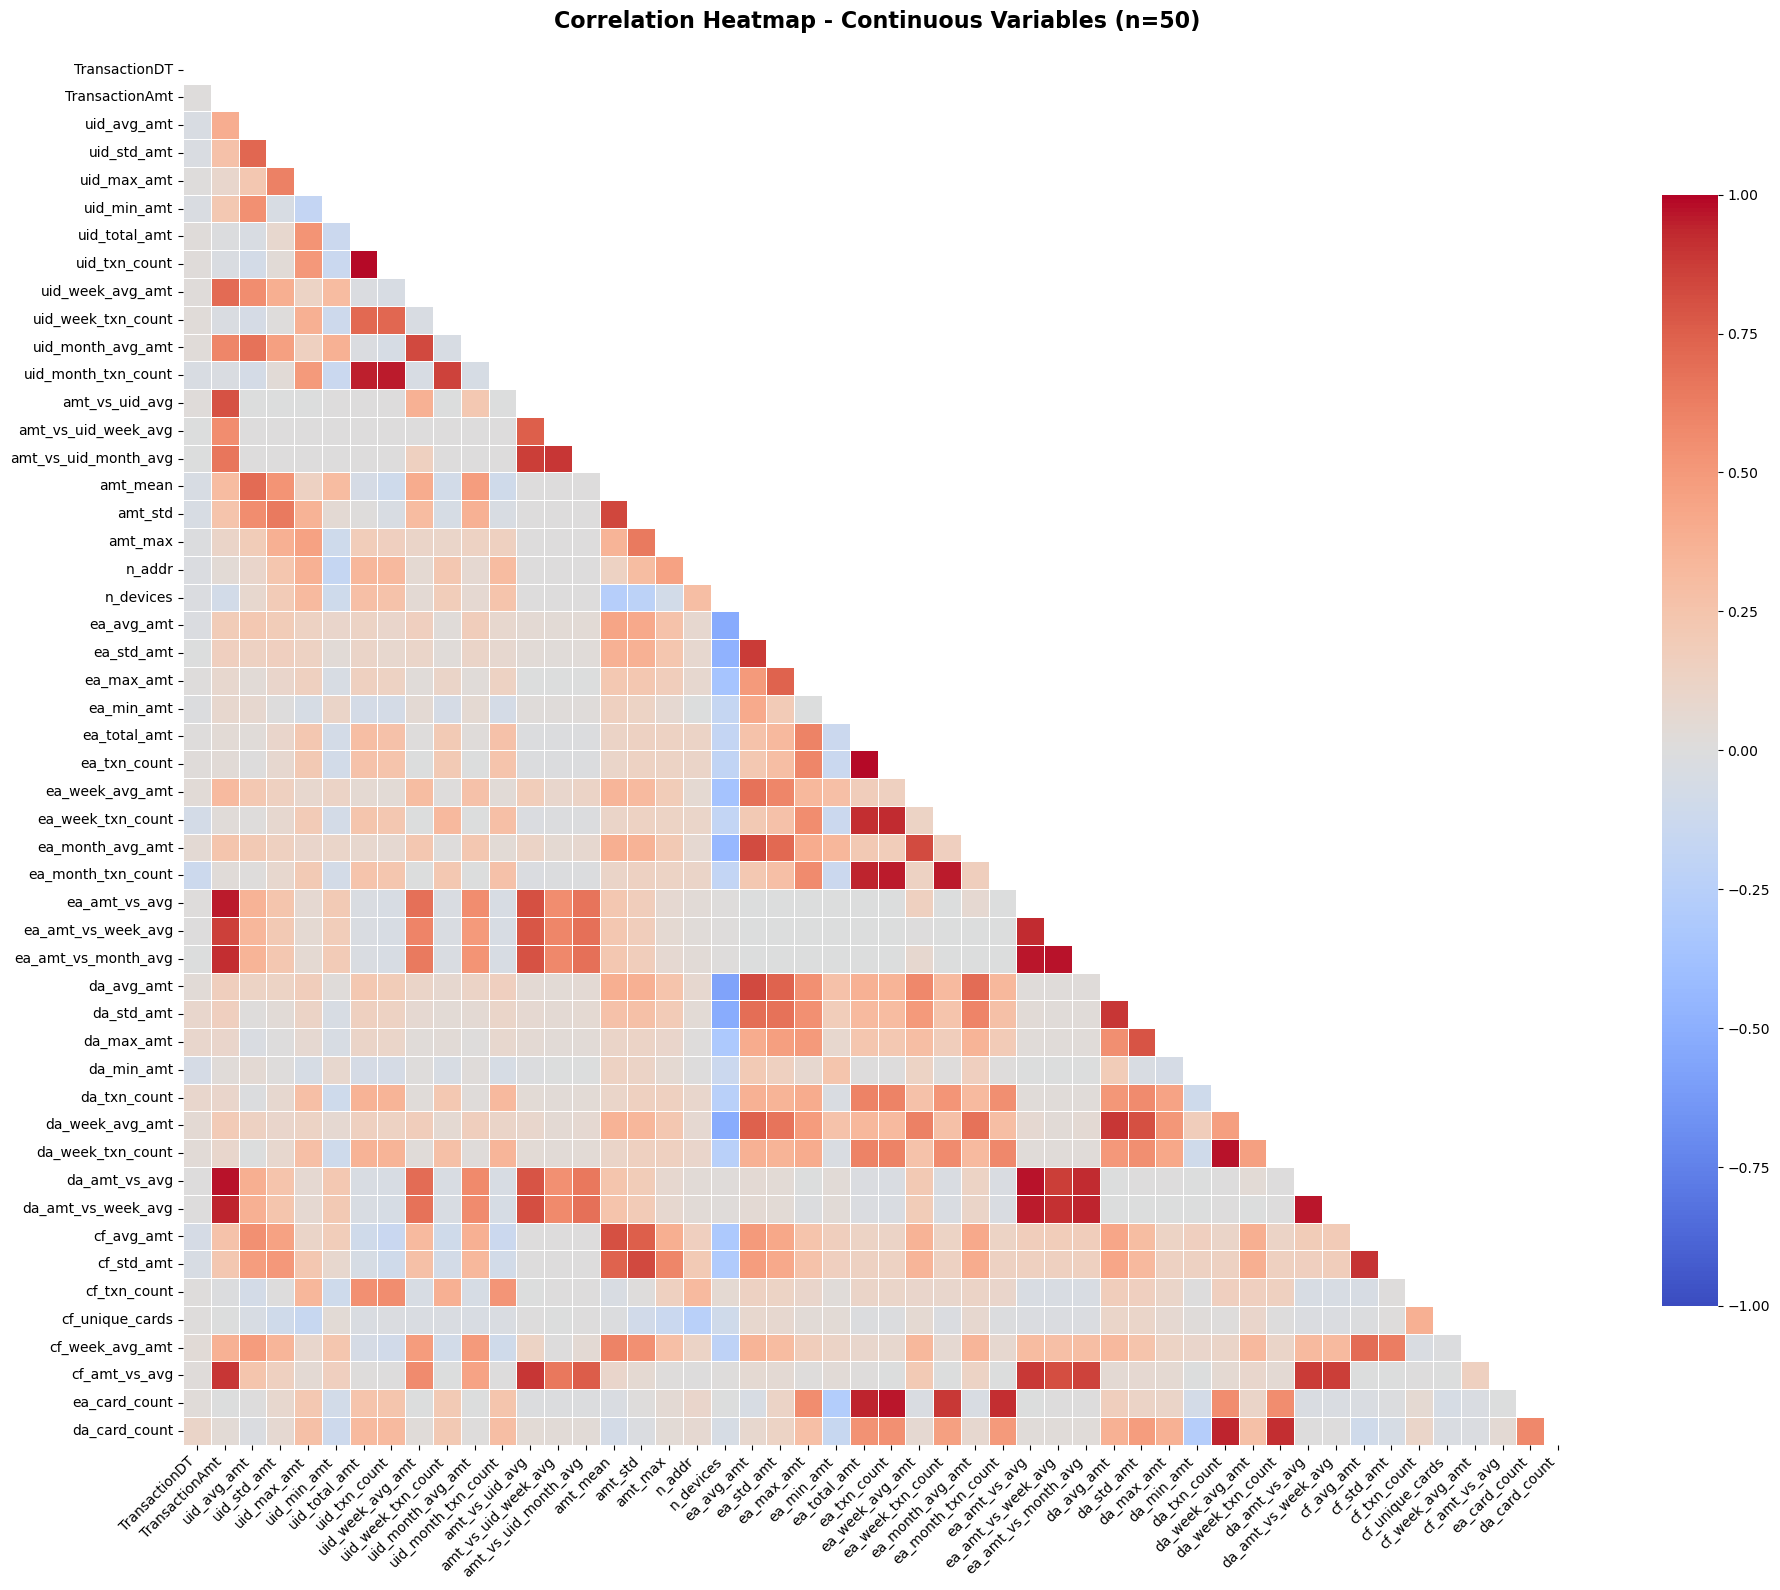


✅ Correlation analysis completed!


In [31]:
# ==================== CORRELATION HEATMAP FOR CONTINUOUS VARIABLES ====================

print("\n" + "="*80)
print("MULTICOLLINEARITY ANALYSIS - CONTINUOUS VARIABLES")
print("="*80)

# Use the same list from previous cell (without suffixes like _1, _2, _3)
# Clean feature names by removing number suffixes
dropped_features = [feat.replace('_1', '').replace('_2', '').replace('_3', '').replace('_freq', '') 
                    for feat in low_importance_to_drop]
dropped_features = list(set(dropped_features))  # Remove duplicates

print(f"Excluding {len(dropped_features)} dropped features from correlation analysis")

# Use other_cols from previous cell (already filtered engineered features)
# Get only continuous numerical columns from the selected features
continuous_cols = []
for col in other_cols:
    # Skip dropped features
    if any(col.startswith(feat) or col == feat for feat in dropped_features):
        continue
    if train_df[col].dtype in ['float64', 'float32', 'int64', 'int32']:
        # Check if it's truly continuous (not binary or low cardinality categorical)
        nunique = train_df[col].nunique()
        if nunique > 20:  # More than 20 unique values = continuous
            continuous_cols.append(col)

print(f"\n📊 Found {len(continuous_cols)} continuous variables")
print(f"\nContinuous variables:")
for i, col in enumerate(continuous_cols, 1):
    print(f"  {i:2d}. {col}")

# Calculate correlation matrix
print(f"\n{'='*80}")
print("Calculating correlation matrix...")
print(f"{'='*80}")

corr_matrix = train_df[continuous_cols].corr()

# Find highly correlated pairs (|correlation| > 0.8)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'var1': corr_matrix.columns[i],
                'var2': corr_matrix.columns[j],
                'correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    print(f"\n⚠️ HIGH CORRELATION PAIRS (|r| > 0.8): {len(high_corr_pairs)}")
    print("-" * 80)
    for pair in sorted(high_corr_pairs, key=lambda x: abs(x['correlation']), reverse=True):
        print(f"  {pair['var1']:<35} ↔ {pair['var2']:<35} : {pair['correlation']:>6.3f}")
else:
    print(f"\n✓ No high correlation pairs found (|r| > 0.8)")

# Create correlation heatmap
print(f"\n{'='*80}")
print("Creating correlation heatmap...")
print(f"{'='*80}")

plt.figure(figsize=(20, 16))

# Use mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Create heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True if len(continuous_cols) <= 15 else False,  # Annotate only if <= 15 vars
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    vmin=-1, 
    vmax=1
)

plt.title(f'Correlation Heatmap - Continuous Variables (n={len(continuous_cols)})', 
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

print(f"\n✅ Correlation analysis completed!")
print(f"{'='*80}")

In [ ]:
# ==================== DROP HIGH CORRELATION FEATURES ====================

if high_corr_pairs:
    print("\n" + "="*80)
    print("DROPPING FEATURES WITH HIGH CORRELATION")
    print("="*80)
    
    # For each high correlation pair, keep the feature that has higher importance
    # If importance not yet calculated, keep the first one by default
    features_to_drop = set()
    
    for pair in sorted(high_corr_pairs, key=lambda x: abs(x['correlation']), reverse=True):
        var1, var2 = pair['var1'], pair['var2']
        
        # If neither feature is already marked for dropping
        if var1 not in features_to_drop and var2 not in features_to_drop:
            # Drop var2 by default (can be optimized with feature importance later)
            features_to_drop.add(var2)
            print(f"  ✓ Marking to drop: {var2} (corr={pair['correlation']:.3f} with {var1})")
    
    if features_to_drop:
        features_to_drop_list = list(features_to_drop)
        
        # ONLY update other_cols list - actual dropping happens during df_model creation
        other_cols = [col for col in other_cols if col not in features_to_drop_list]
        
        print(f"\n{'='*80}")
        print(f"✓ Marked {len(features_to_drop)} features for exclusion")
        print(f"✓ Updated other_cols list: {len(other_cols)} features remaining")
        print(f"\n📝 These features will be excluded when creating df_model in next step")
        print(f"{'='*80}")
    else:
        print(f"\n⚠️ No features to drop")
else:
    print("\n✓ No features to drop - correlation matrix is clean!")


DROPPING FEATURES WITH HIGH CORRELATION
  ✓ Dropping uid_txn_count (corr=0.989 with uid_total_amt)
  ✓ Dropping ea_txn_count (corr=0.986 with ea_total_amt)
  ✓ Dropping da_week_txn_count (corr=0.976 with da_txn_count)
  ✓ Dropping da_amt_vs_avg (corr=0.973 with ea_amt_vs_avg)
  ✓ Dropping ea_amt_vs_month_avg (corr=0.970 with ea_amt_vs_week_avg)
  ✓ Dropping ea_month_txn_count (corr=0.960 with ea_week_txn_count)
  ✓ Dropping ea_amt_vs_avg (corr=0.958 with TransactionAmt)
  ✓ Dropping uid_month_txn_count (corr=0.945 with uid_total_amt)
  ✓ Dropping ea_card_count (corr=0.944 with ea_total_amt)
  ✓ Dropping da_amt_vs_week_avg (corr=0.944 with TransactionAmt)
  ✓ Dropping da_card_count (corr=0.942 with da_txn_count)
  ✓ Dropping ea_week_txn_count (corr=0.916 with ea_total_amt)
  ✓ Dropping cf_std_amt (corr=0.903 with cf_avg_amt)
  ✓ Dropping da_std_amt (corr=0.897 with da_avg_amt)
  ✓ Dropping cf_amt_vs_avg (corr=0.897 with TransactionAmt)
  ✓ Dropping da_week_avg_amt (corr=0.895 with da_a

In [35]:
# ==================== ENCODING & PREPROCESSING ====================

from sklearn.preprocessing import LabelEncoder

print("\n" + "="*80)
print("ENCODING CATEGORICAL FEATURES")
print("="*80)

# Use updated other_cols list (after dropping high correlation features)
feature_cols = other_cols
df_model = train_df[feature_cols + ['isFraud']].copy()

# Identify categorical columns
categorical_cols = [col for col in feature_cols if df_model[col].dtype in ['object', 'category']]
categorical_high_card = [col for col in categorical_cols if df_model[col].nunique() > 50]

numeric_cols = [col for col in feature_cols if df_model[col].dtype in ['int64', 'float64', 'int32', 'int8', 'int16', 'float32']]
numeric_but_categorical = [col for col in numeric_cols if df_model[col].nunique() < 20]

print(f"\nCategorical columns: {len(categorical_cols)}")
print(f"  - High cardinality (>50): {len(categorical_high_card)}")
print(f"Numeric columns: {len(numeric_cols)}")
print(f"  - Numeric but categorical (<20): {len(numeric_but_categorical)}")

# Separate into encoding categories
cat_cols_low = [col for col in categorical_cols if col not in categorical_high_card]
numeric_only = [col for col in numeric_cols if col not in numeric_but_categorical]
numeric_as_cat = numeric_but_categorical
high_card_cols = categorical_high_card

print(f"\n{'='*80}")
print("ENCODING STRATEGY:")
print(f"  - Low cardinality categorical (Label Encoding): {len(cat_cols_low)}")
print(f"  - High cardinality categorical (Frequency Encoding): {len(high_card_cols)}")
print(f"  - Numeric only: {len(numeric_only)}")
print(f"  - Numeric as categorical: {len(numeric_as_cat)}")
print("="*80)

# Label Encoding for low cardinality categoricals
le_dict = {}
for col in cat_cols_low:
    le = LabelEncoder()
    df_model[col] = df_model[col].astype(str).replace({'nan': 'MISSING', 'None': 'MISSING', '<NA>': 'MISSING'})
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    print(f"  ✓ Label Encoded {col}: {len(le.classes_)} unique values")

# Numeric but categorical columns
for col in numeric_as_cat:
    unique_count = df_model[col].nunique()
    if unique_count < 10:
        # One-Hot Encoding
        df_model = pd.get_dummies(df_model, columns=[col], prefix=col, drop_first=True)
        print(f"  ✓ One-Hot Encoded {col}: {unique_count} categories")
    else:
        # Label Encoding
        le = LabelEncoder()
        df_model[col] = df_model[col].astype(str).replace({'nan': 'MISSING', 'None': 'MISSING'})
        df_model[col] = le.fit_transform(df_model[col])
        le_dict[col] = le
        print(f"  ✓ Label Encoded {col}: {unique_count} unique values")

# Frequency Encoding for high cardinality
freq_maps = {}
for col in high_card_cols:
    freq_map = df_model[col].value_counts().to_dict()
    df_model[f'{col}_freq'] = df_model[col].map(freq_map).fillna(0)
    df_model = df_model.drop(col, axis=1)
    freq_maps[col] = freq_map
    print(f"  ✓ Frequency Encoded {col}: {len(freq_map)} unique → {col}_freq")

# Fill missing values in numeric columns
for col in numeric_only:
    if col in df_model.columns and df_model[col].isna().any():
        df_model[col] = df_model[col].fillna(-999)
        print(f"  ✓ Filled NA in {col} with -999")

print(f"\n{'='*80}")
print("Encoding completed!")
print(f"{'='*80}")


ENCODING CATEGORICAL FEATURES

Categorical columns: 15
  - High cardinality (>50): 12
Numeric columns: 40
  - Numeric but categorical (<20): 14

ENCODING STRATEGY:
  - Low cardinality categorical (Label Encoding): 3
  - High cardinality categorical (Frequency Encoding): 12
  - Numeric only: 26
  - Numeric as categorical: 14
  ✓ Label Encoded ProductCD: 5 unique values

Categorical columns: 15
  - High cardinality (>50): 12
Numeric columns: 40
  - Numeric but categorical (<20): 14

ENCODING STRATEGY:
  - Low cardinality categorical (Label Encoding): 3
  - High cardinality categorical (Frequency Encoding): 12
  - Numeric only: 26
  - Numeric as categorical: 14
  ✓ Label Encoded ProductCD: 5 unique values
  ✓ Label Encoded card4: 5 unique values
  ✓ Label Encoded card6: 5 unique values
  ✓ Label Encoded card4: 5 unique values
  ✓ Label Encoded card6: 5 unique values
  ✓ One-Hot Encoded is_round_amount: 2 categories
  ✓ One-Hot Encoded is_psych_amount: 2 categories
  ✓ One-Hot Encoded is_

In [ ]:
# ==================== DROP LOW IMPORTANCE FEATURES (AFTER ENCODING) ====================

print("="*80)
print("DROPPING LOW IMPORTANCE FEATURES (AFTER ENCODING)")
print("="*80)

# These features have low/zero importance based on previous model runs
# They are created during encoding (one-hot encoding adds _1, _2 suffixes)
low_importance_after_encoding = [
    'is_99_cents_1',
    'has_cents_1',
    'multi_card_risk_score_3',
    'multi_card_risk_score_2',
    'multi_card_risk_score_1',
    'is_random_amount_1',
    'is_psych_amount_1',
    'is_95_cents_1',
    'is_round_amount_1',
    'is_multi_card_family_1',
    'is_multi_card_email_addr_1',
    'is_multi_card_device_addr_1',
    'ea_is_new_1',
    'da_is_new_1',
    'identity_device_addr_freq',  # High cardinality freq encoding
    'addr2_freq'  # High cardinality freq encoding
]

# Check which columns exist in df_model
existing_cols = [col for col in low_importance_after_encoding if col in df_model.columns]
missing_cols = [col for col in low_importance_after_encoding if col not in df_model.columns]

print(f"\n📋 Features to drop: {len(low_importance_after_encoding)}")
print(f"✓ Found in df_model: {len(existing_cols)}")
print(f"⚠️ Not found: {len(missing_cols)}")

if existing_cols:
    print(f"\n🗑️ Dropping {len(existing_cols)} features:")
    for col in existing_cols:
        print(f"  - {col}")
    
    df_model = df_model.drop(columns=existing_cols)
    print(f"\n✅ Successfully dropped {len(existing_cols)} low importance features")
else:
    print(f"\n⚠️ No features found to drop")

if missing_cols:
    print(f"\n📝 Features not found (may have been renamed/dropped):")
    for col in missing_cols[:5]:  # Show first 5
        print(f"  - {col}")
    if len(missing_cols) > 5:
        print(f"  ... and {len(missing_cols)-5} more")

print(f"\n{'='*80}")
print(f"df_model shape after dropping: {df_model.shape}")
print(f"{'='*80}")

In [36]:
# ==================== PREPARE X and y ====================

y = df_model['isFraud']
X = df_model.drop(['isFraud'], axis=1)

# Remove TransactionDT for modeling (time leakage)
time_col = 'TransactionDT'
if time_col in X.columns:
    X = X.drop([time_col], axis=1)
    print(f"✓ Dropped {time_col} for modeling (time leakage)")

print(f"\n{'='*80}")
print(f"FINAL X AND Y")
print(f"{'='*80}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Fraud rate: {y.mean()*100:.2f}%")
print(f"\nFeatures used: {X.shape[1]}")

✓ Dropped TransactionDT for modeling (time leakage)

FINAL X AND Y
X shape: (590540, 58)
y shape: (590540,)
Fraud rate: 3.50%

Features used: 58


In [37]:
# ==================== MODEL TRAINING ====================

from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_curve
from lightgbm import LGBMClassifier

print("\n" + "="*80)
print("CROSS VALIDATION (TimeSeriesSplit)")
print("="*80)

model_cv = LGBMClassifier(n_estimators=1000, learning_rate=0.01, verbose=-1, n_jobs=-1)

scores = cross_val_score(
    model_cv, 
    X, 
    y, 
    cv=TimeSeriesSplit(n_splits=5),
    scoring='roc_auc',
    n_jobs=-1
)

print(f"CV AUC: {scores.mean():.6f} (+/- {scores.std():.6f})")
print(f"CV Scores per fold: {[f'{s:.4f}' for s in scores]}")

# Train-Test Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n{'='*80}")
print(f"Train size: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val size: {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Fraud rate - Train: {y_train.mean()*100:.2f}%, Val: {y_val.mean()*100:.2f}%")

# Train LightGBM
print(f"\n{'='*80}")
print("Training LightGBM model...")
print("="*80)

lgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=31,
    random_state=42,
    class_weight='balanced',
    verbose=-1,
    n_jobs=-1
)

lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc'
)

# Predictions & Metrics
y_train_pred_proba = lgbm_model.predict_proba(X_train)[:, 1]
y_val_pred_proba = lgbm_model.predict_proba(X_val)[:, 1]
y_val_pred = lgbm_model.predict(X_val)

train_auc = roc_auc_score(y_train, y_train_pred_proba)
val_auc = roc_auc_score(y_val, y_val_pred_proba)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print(f"\n{'='*80}")
print(f"MODEL RESULTS - ADVANCED FEATURES")
print(f"{'='*80}")
print(f"🎯 CV ROC-AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")
print(f"🎯 Train ROC-AUC: {train_auc:.4f}")
print(f"🎯 Val ROC-AUC: {val_auc:.4f}")
print(f"   Val Precision: {precision:.4f}")
print(f"   Val Recall: {recall:.4f}")
print(f"   Val F1-Score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)
print(f"\nConfusion Matrix:")
print(cm)


CROSS VALIDATION (TimeSeriesSplit)
CV AUC: 0.852482 (+/- 0.018604)
CV Scores per fold: ['0.8170', '0.8682', '0.8543', '0.8670', '0.8558']
CV AUC: 0.852482 (+/- 0.018604)
CV Scores per fold: ['0.8170', '0.8682', '0.8543', '0.8670', '0.8558']

Train size: 472,432 (80.0%)
Val size: 118,108 (20.0%)
Fraud rate - Train: 3.50%, Val: 3.50%

Training LightGBM model...

Train size: 472,432 (80.0%)
Val size: 118,108 (20.0%)
Fraud rate - Train: 3.50%, Val: 3.50%

Training LightGBM model...

MODEL RESULTS - ADVANCED FEATURES
🎯 CV ROC-AUC: 0.8525 (+/- 0.0186)
🎯 Train ROC-AUC: 0.9471
🎯 Val ROC-AUC: 0.9251
   Val Precision: 0.1823
   Val Recall: 0.8425
   Val F1-Score: 0.2997

Confusion Matrix:
[[98352 15623]
 [  651  3482]]

MODEL RESULTS - ADVANCED FEATURES
🎯 CV ROC-AUC: 0.8525 (+/- 0.0186)
🎯 Train ROC-AUC: 0.9471
🎯 Val ROC-AUC: 0.9251
   Val Precision: 0.1823
   Val Recall: 0.8425
   Val F1-Score: 0.2997

Confusion Matrix:
[[98352 15623]
 [  651  3482]]


In [38]:
# ==================== FEATURE IMPORTANCE ====================

feature_importance = pd.DataFrame({
    'feature': X.columns.tolist(),
    'importance': lgbm_model.feature_importances_
}).sort_values('importance', ascending=False)

# Calculate importance percentage
total_importance = feature_importance['importance'].sum()
feature_importance['importance_pct'] = (feature_importance['importance'] / total_importance) * 100

print(f"\n{'='*80}")
print("FEATURE IMPORTANCE - TOP 30")
print(f"{'='*80}")

for idx, row in feature_importance.head(30).iterrows():
    pct = row['importance_pct']
    bar = '█' * int(pct * 2)  # Visual bar
    print(f"{row['feature']:<35}: {row['importance']:>8,.0f} ({pct:>5.2f}%) {bar}")

print(f"\n{'='*80}")
print(f"Top 10 contribute: {feature_importance.head(10)['importance_pct'].sum():.1f}%")
print(f"Top 20 contribute: {feature_importance.head(20)['importance_pct'].sum():.1f}%")
print(f"Top 30 contribute: {feature_importance.head(30)['importance_pct'].sum():.1f}%")
print(f"Top 40 contribute: {feature_importance.head(40)['importance_pct'].sum():.1f}%")
print(f"Top 50 contribute: {feature_importance.head(50)['importance_pct'].sum():.1f}%")
print(f"Top 60 contribute: {feature_importance.head(60)['importance_pct'].sum():.1f}%")
print(f"Top 65 contribute: {feature_importance.head(65)['importance_pct'].sum():.1f}%")



print(f"{'='*80}")


FEATURE IMPORTANCE - TOP 30
user_anchor_D1                     :    1,811 (12.07%) ████████████████████████
TransactionAmt                     :      804 ( 5.36%) ██████████
amt_mean                           :      539 ( 3.59%) ███████
ea_avg_amt                         :      482 ( 3.21%) ██████
uid_avg_amt                        :      460 ( 3.07%) ██████
amt_max                            :      451 ( 3.01%) ██████
card1_freq                         :      422 ( 2.81%) █████
uid_total_amt                      :      416 ( 2.77%) █████
dist1                              :      412 ( 2.75%) █████
uid_max_amt                        :      409 ( 2.73%) █████
uid_min_amt                        :      405 ( 2.70%) █████
uid_card1_addr1_freq               :      401 ( 2.67%) █████
da_max_amt                         :      400 ( 2.67%) █████
uid_week_txn_count                 :      396 ( 2.64%) █████
card2_freq                         :      377 ( 2.51%) █████
P_emaildomain_freq         

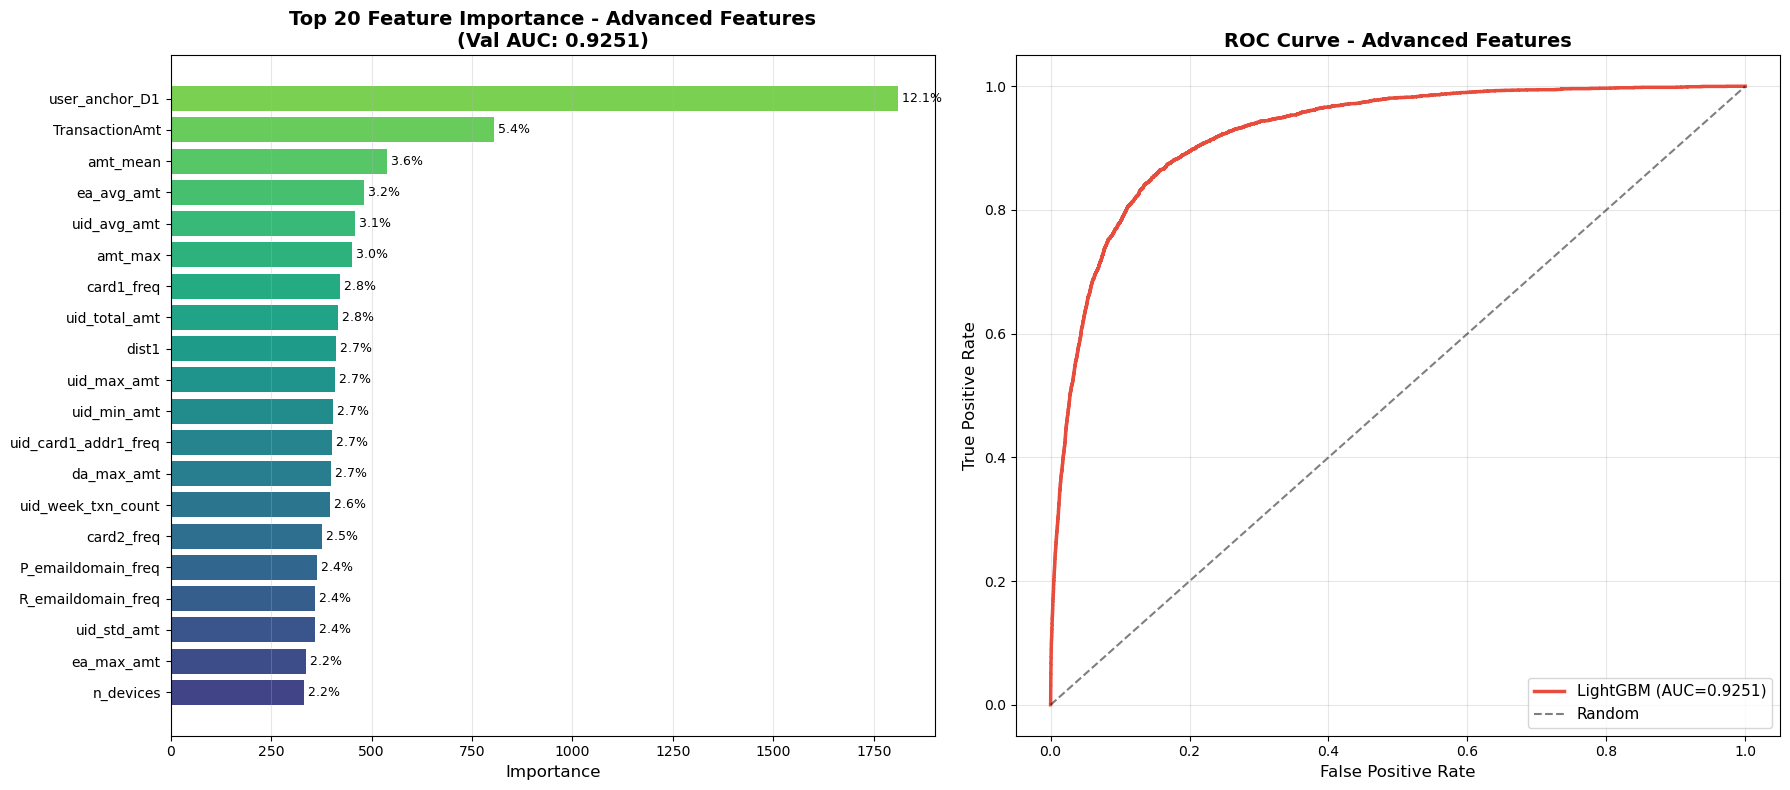


✅ Visualization completed!


In [39]:
# ==================== VISUALIZATION ====================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Feature Importance (Top 20)
ax1 = axes[0]
top_20_features = feature_importance.head(20)
colors = plt.cm.viridis(np.linspace(0.8, 0.2, len(top_20_features)))
bars = ax1.barh(range(len(top_20_features)), top_20_features['importance'], color=colors)
ax1.set_yticks(range(len(top_20_features)))
ax1.set_yticklabels(top_20_features['feature'])
ax1.invert_yaxis()
ax1.set_xlabel('Importance', fontsize=12)
ax1.set_title(f'Top 20 Feature Importance - Advanced Features\n(Val AUC: {val_auc:.4f})', 
              fontweight='bold', fontsize=14)
ax1.grid(alpha=0.3, axis='x')

# Add percentage labels
for i, (idx, row) in enumerate(top_20_features.iterrows()):
    ax1.text(row['importance'], i, f" {row['importance_pct']:.1f}%", 
             va='center', fontsize=9, color='black')

# ROC Curve
ax2 = axes[1]
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
ax2.plot(fpr, tpr, color='#e74c3c', linewidth=2.5, label=f'LightGBM (AUC={val_auc:.4f})')
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('ROC Curve - Advanced Features', fontweight='bold', fontsize=14)
ax2.legend(loc='lower right', fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*80}")
print("✅ Visualization completed!")
print(f"{'='*80}")

In [43]:
# ==================== LOW IMPORTANCE ANALYSIS ====================

# Find features with very low importance (<0.1%)
very_low_importance = feature_importance[feature_importance['importance_pct'] < 0.1]['feature'].tolist()
zero_importance = feature_importance[feature_importance['importance'] == 0]['feature'].tolist()

print("="*80)
print("LOW IMPORTANCE FEATURE ANALYSIS")
print("="*80)

print(f"\n❌ Zero Importance Features ({len(zero_importance)}):")
for feat in zero_importance[:10]:
    print(f"  - {feat}")
if len(zero_importance) > 10:
    print(f"  ... and {len(zero_importance)-10} more")

print(f"\n⚠️ Very Low Importance Features (<0.1%) ({len(very_low_importance)}):")
for feat in very_low_importance[:15]:
    imp_pct = feature_importance[feature_importance['feature'] == feat]['importance_pct'].values[0]
    print(f"  - {feat}: {imp_pct:.3f}%")
if len(very_low_importance) > 15:
    print(f"  ... and {len(very_low_importance)-15} more")

print(f"\n{'='*80}")
print(f"💡 Recommendation: Consider dropping {len(zero_importance) + len(very_low_importance)} low-value features")
print(f"{'='*80}")

LOW IMPORTANCE FEATURE ANALYSIS

❌ Zero Importance Features (5):
  - da_is_new_1
  - ea_is_new_1
  - is_multi_card_family_1
  - is_multi_card_email_addr_1
  - has_cents_1

⚠️ Very Low Importance Features (<0.1%) (10):
  - multi_card_risk_score_1: 0.087%
  - is_round_amount_1: 0.047%
  - addr2_freq: 0.027%
  - multi_card_risk_score_3: 0.027%
  - is_multi_card_device_addr_1: 0.007%
  - da_is_new_1: 0.000%
  - ea_is_new_1: 0.000%
  - is_multi_card_family_1: 0.000%
  - is_multi_card_email_addr_1: 0.000%
  - has_cents_1: 0.000%

💡 Recommendation: Consider dropping 15 low-value features


In [44]:
# ==================== LOW IMPORTANCE FEATURES LIST ====================

print("="*80)
print("LOW IMPORTANCE FEATURES - DETAILED LIST")
print("="*80)

print(f"\n❌ ZERO IMPORTANCE FEATURES ({len(zero_importance)}):")
print("-" * 40)
for i, feat in enumerate(zero_importance, 1):
    print(f"  {i}. {feat}")

print(f"\n⚠️ VERY LOW IMPORTANCE FEATURES (<0.1%) ({len(very_low_importance)}):")
print("-" * 40)
for i, feat in enumerate(very_low_importance, 1):
    imp_pct = feature_importance[feature_importance['feature'] == feat]['importance_pct'].values[0]
    print(f"  {i}. {feat:<40} : {imp_pct:.4f}%")

# Combined list for potential removal
all_low_features = list(set(zero_importance + very_low_importance))
print(f"\n📋 ALL LOW IMPORTANCE FEATURES TO CONSIDER DROPPING ({len(all_low_features)}):")
print("-" * 40)
for i, feat in enumerate(sorted(all_low_features), 1):
    print(f"  {i}. {feat}")

print(f"\n{'='*80}")

LOW IMPORTANCE FEATURES - DETAILED LIST

❌ ZERO IMPORTANCE FEATURES (5):
----------------------------------------
  1. da_is_new_1
  2. ea_is_new_1
  3. is_multi_card_family_1
  4. is_multi_card_email_addr_1
  5. has_cents_1

⚠️ VERY LOW IMPORTANCE FEATURES (<0.1%) (10):
----------------------------------------
  1. multi_card_risk_score_1                  : 0.0867%
  2. is_round_amount_1                        : 0.0467%
  3. addr2_freq                               : 0.0267%
  4. multi_card_risk_score_3                  : 0.0267%
  5. is_multi_card_device_addr_1              : 0.0067%
  6. da_is_new_1                              : 0.0000%
  7. ea_is_new_1                              : 0.0000%
  8. is_multi_card_family_1                   : 0.0000%
  9. is_multi_card_email_addr_1               : 0.0000%
  10. has_cents_1                              : 0.0000%

📋 ALL LOW IMPORTANCE FEATURES TO CONSIDER DROPPING (10):
----------------------------------------
  1. addr2_freq
  2. da_is_

In [46]:
all_low_features

['multi_card_risk_score_1',
 'is_multi_card_email_addr_1',
 'ea_is_new_1',
 'multi_card_risk_score_3',
 'is_multi_card_device_addr_1',
 'addr2_freq',
 'is_multi_card_family_1',
 'has_cents_1',
 'is_round_amount_1',
 'da_is_new_1']

In [ ]:
# ==================== FINAL SUMMARY ====================

print("\n" + "="*80)
print("🎯 FINAL MODEL SUMMARY - ADVANCED FEATURE ENGINEERING")
print("="*80)

print(f"\n📊 DATASET:")
print(f"  - Total features used: {X.shape[1]}")
print(f"  - Training samples: {len(X_train):,}")
print(f"  - Validation samples: {len(X_val):,}")
print(f"  - Fraud rate: {y.mean()*100:.2f}%")

print(f"\n🎯 MODEL PERFORMANCE:")
print(f"  - CV ROC-AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")
print(f"  - Train ROC-AUC: {train_auc:.4f}")
print(f"  - Validation ROC-AUC: {val_auc:.4f}")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall: {recall:.4f}")
print(f"  - F1-Score: {f1:.4f}")

print(f"\n⭐ TOP 5 MOST IMPORTANT FEATURES:")
for i, (idx, row) in enumerate(feature_importance.head(5).iterrows(), 1):
    print(f"  {i}. {row['feature']:<35} ({row['importance_pct']:.2f}%)")

print(f"\n{'='*80}")
print("✅ Feature engineering and model training completed!")
print(f"{'='*80}")


🎯 FINAL MODEL SUMMARY - ADVANCED FEATURE ENGINEERING

📊 DATASET:
  - Total features used: 84
  - Training samples: 472,432
  - Validation samples: 118,108
  - Fraud rate: 3.50%

🎯 MODEL PERFORMANCE:
  - CV ROC-AUC: 0.8530 (+/- 0.0184)
  - Train ROC-AUC: 0.9486
  - Validation ROC-AUC: 0.9240
  - Precision: 0.1839
  - Recall: 0.8357
  - F1-Score: 0.3015

⭐ TOP 5 MOST IMPORTANT FEATURES:
  1. user_anchor_D1                      (10.01%)
  2. dist1                               (2.31%)
  3. TransactionAmt                      (2.29%)
  4. uid_max_amt                         (2.24%)
  5. card1_freq                          (2.17%)

✅ Feature engineering and model training completed!


## 📊 Feature Summary - OPTIMIZED (04 Model Tabanlı)

### 🏆 TOP PRIORITY FEATURES (04'te Top 20)

#### Core User Features (5 features)
- ⭐ `user_anchor_D1` (12.90% imp) - #1 feature
- `uid_card1_addr1`: User ID
- `amt_mean` (5.61% imp), `amt_std` (2.49% imp), `amt_max` (2.69% imp)
- `n_devices` (2.07% imp)

#### UID Behavioral Features (~13 features)
- `uid_avg_amt` (2.71% imp), `uid_max_amt` (2.65% imp), `uid_min_amt` (2.61% imp)
- `uid_std_amt` (2.07% imp), `uid_txn_count` (2.06% imp), `uid_total_amt` (2.41% imp)
- `uid_week_avg_amt`, `uid_week_txn_count` (2.55% imp)
- `uid_month_avg_amt` (2.39% imp), `uid_month_txn_count` (2.30% imp)
- Anomaly ratios: `amt_vs_uid_avg`, `amt_vs_uid_week_avg`, `amt_vs_uid_month_avg`

#### Multi-Card Detection (4 features)
- `email_addr_card_count` (2.51% imp) ✅
- `email_card_count` (2.25% imp) ✅
- `browser_card_count` (2.29% imp) ✅
- `device_card_count` (bonus)

### 📧 Email+Address Features (~13 features)
- **Aggregations**: ea_avg_amt, ea_std_amt, ea_max_amt, ea_min_amt, ea_total_amt, ea_txn_count
- **Temporal**: ea_week_avg_amt, ea_week_txn_count, ea_month_avg_amt, ea_month_txn_count
- **Anomaly**: ea_amt_vs_avg, ea_amt_vs_week_avg, ea_amt_vs_month_avg

### 📱 Device+Address Features (~9 features)
- **Aggregations**: da_avg_amt, da_std_amt, da_max_amt, da_min_amt, da_txn_count
- **Temporal**: da_week_avg_amt, da_week_txn_count
- **Anomaly**: da_amt_vs_avg, da_amt_vs_week_avg

### 💳 Card Family Features (~7 features)
- **Aggregations**: cf_avg_amt, cf_std_amt, cf_txn_count, cf_unique_cards
- **Temporal**: cf_week_avg_amt
- **Anomaly**: cf_amt_vs_avg

### 🚫 DROPPED FEATURES (0% Importance in 04)
- ❌ `is_multi_card_family` (0% imp)
- ❌ `is_multi_card_device` (0% imp)
- ❌ `is_multi_card_address` (0% imp)
- ❌ `multi_card_risk_score` (sum of useless flags)

**Total: ~50 yeni feature** (gereksizler çıkarılmış, önemliler eklenmiş) 🎯

---

## 🔍 Notebook İçeriği

1. **STEP 1**: Identity Resolution (3 identity types)
2. **STEP 2**: Core User Features (UID, user_anchor_D1, card1 stats)
3. **STEP 3**: Temporal Features (week_num, month_num)
4. **STEP 4**: UID Behavioral Features (en önemli)
5. **STEP 5**: Email+Addr, Device+Addr, Card Family Features
6. **STEP 6**: Multi-Card Detection (optimized)
7. **STEP 7**: New User Indicators & Missing Values
8. **STEP 8**: Cleanup & Summary
9. **STEP 9**: Save Dataset
10. **STEP 10**: Model Training & Feature Importance Analysis

✅ **Bu notebook feature engineering + model validation içeriyor!**